# Punto 2 — Clasificación multiclase con CvT simplificado

Nombre: **Lorena Anavia Coihuin**

Curso: *Deep Learning*

Profesor: *Reinel Tabares Soto*

En esta sección implementamos un modelo basado en Convolutional Vision Transformer (CvT) para clasificar imágenes de Fashion-MNIST. La idea central es combinar una extracción local de características mediante convoluciones con un mecanismo de atención que permita relacionar distintas regiones de la imagen.

Usaremos una versión simplificada de CvT para mantener el flujo del modelo claro y manejable. Esto nos permite concentrarnos en el embedding convolucional, el bloque Transformer y la cabeza de clasificación, además de validar el comportamiento con accuracy y matriz de confusión.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Preparación de los datos

Aquí cargamos Fashion-MNIST, normalizamos los valores de píxeles al rango 0-1 y agregamos una dimensión de canal. Con esto dejamos las imágenes listas para entrar a las capas convolucionales del modelo.

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Forma x_train:", x_train.shape)
print("Forma y_train:", y_train.shape)
print("Forma x_test:", x_test.shape)
print("Forma y_test:", y_test.shape)
print("Clases:", np.unique(y_train))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma x_train: (60000, 28, 28, 1)
Forma y_train: (60000,)
Forma x_test: (10000, 28, 28, 1)
Forma y_test: (10000,)
Clases: [0 1 2 3 4 5 6 7 8 9]


## Subconjunto de prueba

Antes de entrenar con todo el dataset, usamos un subconjunto pequeño para comprobar que la arquitectura funciona correctamente. Este paso ayuda a detectar errores de forma, de compilación o de flujo antes de invertir más tiempo en el entrenamiento completo.

In [3]:
x_train_small = x_train[:500]
y_train_small = y_train[:500]

x_val_small = x_test[:200]
y_val_small = y_test[:200]

print("Subset entrenamiento:", x_train_small.shape, y_train_small.shape)
print("Subset validación:", x_val_small.shape, y_val_small.shape)

Subset entrenamiento: (500, 28, 28, 1) (500,)
Subset validación: (200, 28, 28, 1) (200,)


## Embedding convolucional

Esta celda construye la primera etapa del CvT. En lugar de convertir la imagen en parches planos, aplicamos una convolución que extrae patrones locales y genera representaciones visuales más ricas desde el inicio.

Después de la convolución, reorganizamos la salida en forma de secuencia para que el Transformer pueda procesarla como tokens. Así conectamos la visión local de las convoluciones con la visión global de la atención.

In [4]:
class ConvTokenEmbedding(layers.Layer):
    def __init__(self, embed_dim=64, kernel_size=3, strides=2, padding="same"):
        super().__init__()
        self.conv = layers.Conv2D(
            filters=embed_dim,
            kernel_size=kernel_size,
            strides=strides,
            padding=padding,
            activation="relu"
        )
        self.norm = layers.LayerNormalization()

    def call(self, x):
        x = self.conv(x)
        print("Después de Conv2D:", x.shape)

        batch_size = tf.shape(x)[0]
        h = tf.shape(x)[1]
        w = tf.shape(x)[2]
        c = tf.shape(x)[3]

        x = tf.reshape(x, [batch_size, h * w, c])
        print("Después de reshape a tokens:", x.shape)

        x = self.norm(x)
        print("Después de LayerNormalization:", x.shape)

        return x

## Bloque Transformer

En esta parte definimos el bloque Transformer simplificado. La atención permite que cada token compare su información con los demás, mientras que la red MLP refina la representación aprendida.

Además, incorporamos conexiones residuales y normalización, que ayudan a estabilizar el entrenamiento y a conservar información importante durante el paso por la red.

In [5]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, mlp_dim=128, dropout_rate=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dropout1 = layers.Dropout(dropout_rate)

        self.norm2 = layers.LayerNormalization()
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim)
        ])
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        print("Entrada al TransformerBlock:", x.shape)

        attn_input = self.norm1(x)
        attn_output = self.attn(attn_input, attn_input)
        attn_output = self.dropout1(attn_output, training=training)

        x = x + attn_output
        print("Después de atención + residual:", x.shape)

        mlp_input = self.norm2(x)
        mlp_output = self.mlp(mlp_input, training=training)
        mlp_output = self.dropout2(mlp_output, training=training)

        x = x + mlp_output
        print("Después de MLP + residual:", x.shape)

        return x

## Construcción del modelo

Aquí ensamblamos el modelo completo: primero el embedding convolucional, luego uno o más bloques Transformer y finalmente una cabeza de clasificación multiclase. Antes de la salida aplicamos global average pooling sobre la secuencia de tokens para obtener una representación compacta.

In [7]:
def build_cvt_model(input_shape=(28, 28, 1), num_classes=10,
                    embed_dim=64, num_heads=4, mlp_dim=128, num_transformer_blocks=2,
                    dropout_rate=0.1):

    inputs = layers.Input(shape=input_shape)

    x = ConvTokenEmbedding(embed_dim=embed_dim)(inputs)

    for i in range(num_transformer_blocks):
        print(f"--- Bloque Transformer {i+1} ---")
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout_rate=dropout_rate
        )(x)

    x = layers.GlobalAveragePooling1D()(x)
    print("Después de GlobalAveragePooling1D:", x.shape)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

cvt_model = build_cvt_model()
cvt_model.summary()

Después de Conv2D: (None, 14, 14, 64)
Después de reshape a tokens: (None, 196, 64)
Después de LayerNormalization: (None, 196, 64)
Después de Conv2D: (None, 14, 14, 64)
Después de reshape a tokens: (None, 196, 64)
Después de LayerNormalization: (None, 196, 64)
--- Bloque Transformer 1 ---
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
--- Bloque Transformer 2 ---
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Después de GlobalAveragePooling1D: (None, 64)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_token_embedding            │ (None, 196, 64)        │           768 │
│ (ConvTokenEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,778 (690.54 KB)

 Trainable params: 176,778 (690.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación y callbacks

En esta etapa configuramos la función de pérdida, el optimizador y los callbacks. Usamos sparse categorical crossentropy porque las etiquetas están codificadas como enteros, y Adam para realizar una optimización estable durante el entrenamiento.

In [8]:
checkpoint_path = "/content/mejor_cvt_fashion_mnist.keras"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

cvt_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente")
print("Checkpoint configurado en:", checkpoint_path)

Modelo compilado correctamente
Checkpoint configurado en: /content/mejor_cvt_fashion_mnist.keras


## Entrenamiento de prueba

Antes de lanzar el entrenamiento completo, realizamos una prueba corta con el subconjunto reducido. Esto nos permite confirmar que el modelo aprende, que la pérdida baja y que la accuracy mejora respecto del azar.

In [9]:
history_small = cvt_model.fit(
    x_train_small, y_train_small,
    validation_data=(x_val_small, y_val_small),
    epochs=3,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/3
Después de Conv2D: (None, 14, 14, 64)
Después de reshape a tokens: (None, 196, 64)
Después de LayerNormalization: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Después de Conv2D: (None, 14, 14, 64)
Después de reshape a tokens: (None, 196, 64)
Después de LayerNormalization: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
Entrada al TransformerBlock: (None, 196, 64)
Después de atención + residual: (None, 196, 64)
Después de MLP + residual: (None, 196, 64)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.1005 - loss: 2.4358Después de Conv2D: (None, 14, 14, 64)
Después de reshape a tokens: (None, 196, 64)
Después de LayerNormalization

## Revisión inicial

Después de la prueba rápida revisamos las métricas básicas del modelo. Aquí verificamos si el comportamiento general es consistente y si vale la pena pasar al entrenamiento completo.

In [10]:
print("Accuracy entrenamiento final (subset):", history_small.history["accuracy"][-1])
print("Accuracy validación final (subset):", history_small.history["val_accuracy"][-1])
print("Loss entrenamiento final (subset):", history_small.history["loss"][-1])
print("Loss validación final (subset):", history_small.history["val_loss"][-1])

Accuracy entrenamiento final (subset): 0.31200000643730164
Accuracy validación final (subset): 0.3149999976158142
Loss entrenamiento final (subset): 1.9858815670013428
Loss validación final (subset): 1.8439773321151733


## Entrenamiento final

Una vez validado el flujo de trabajo, entrenamos el modelo con el dataset completo. En esta fase observamos la evolución de accuracy y loss en entrenamiento y validación para medir si el modelo generaliza adecuadamente.

In [11]:
history = cvt_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=128,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4646 - loss: 1.4364
Epoch 1: val_accuracy improved from 0.38500 to 0.69010, saving model to /content/mejor_cvt_fashion_mnist.keras

Epoch 1: finished saving model to /content/mejor_cvt_fashion_mnist.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.5608 - loss: 1.1688 - val_accuracy: 0.6901 - val_loss: 0.8357
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6974 - loss: 0.8080
Epoch 2: val_accuracy improved from 0.69010 to 0.74110, saving model to /content/mejor_cvt_fashion_mnist.keras

Epoch 2: finished saving model to /content/mejor_cvt_fashion_mnist.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.7103 - loss: 0.7776 - val_accuracy: 0.7411 - val_loss: 0.7085
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7480 - loss: 0.6900
Epoch 3: val_accuracy improved from 0.74110 to 0.76350, saving model to /content/mejor_cvt_fashion_mnist.keras

Epoch 3: finished s

## Curvas de entrenamiento

Al terminar el entrenamiento graficamos accuracy y loss para analizar el aprendizaje del modelo. Estas curvas permiten ver si el rendimiento mejora de manera estable o si aparece sobreajuste.

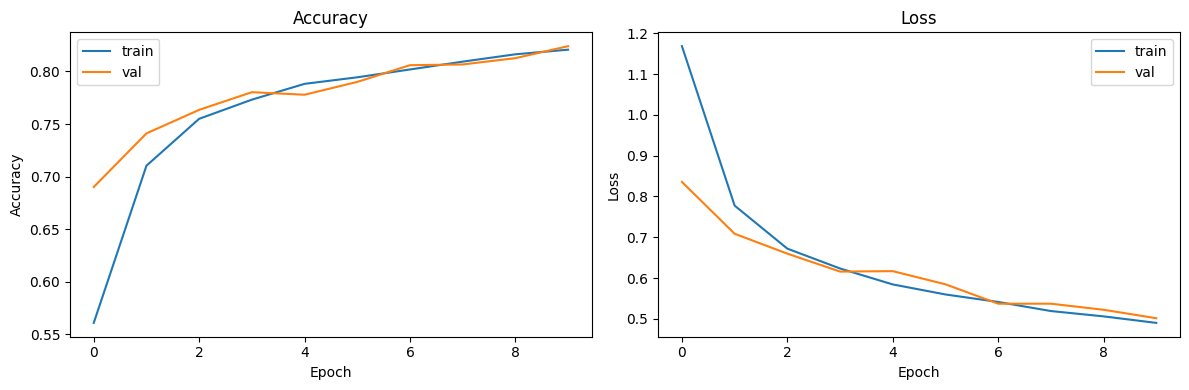

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación final

En la última etapa evaluamos el modelo sobre el conjunto de prueba y construimos la matriz de confusión. La accuracy resume el rendimiento global, mientras que la matriz permite ver en qué clases el modelo se confunde con mayor frecuencia.

Test accuracy: 0.8241000175476074
Test loss: 0.5013567209243774


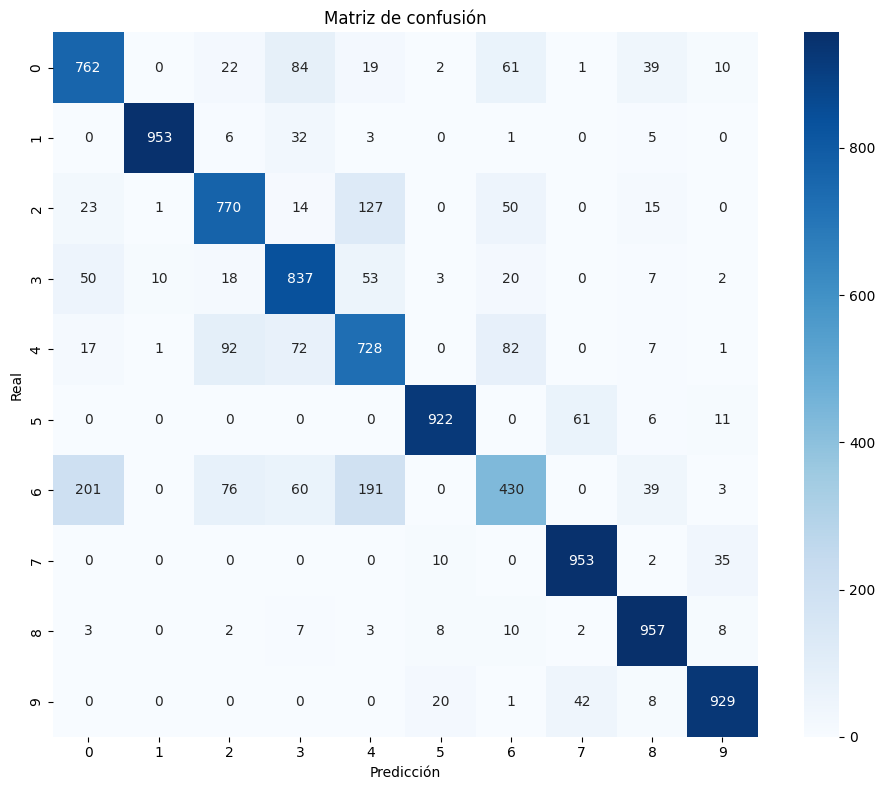

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      1000
           1       0.99      0.95      0.97      1000
           2       0.78      0.77      0.78      1000
           3       0.76      0.84      0.79      1000
           4       0.65      0.73      0.69      1000
           5       0.96      0.92      0.94      1000
           6       0.66      0.43      0.52      1000
           7       0.90      0.95      0.93      1000
           8       0.88      0.96      0.92      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000

Resumen:
Accuracy final en test: 0.8241
Loss final en test: 0.5014
Las clases 1, 5, 7, 8 y 9 muestran el mejor desempeño.
La clase 6 sigue siendo la más difícil por su bajo recall.


In [14]:
test_loss, test_acc = cvt_model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

y_pred = cvt_model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_classes))
print("Resumen:")
print(f"Accuracy final en test: {test_acc:.4f}")
print(f"Loss final en test: {test_loss:.4f}")
print("Las clases 1, 5, 7, 8 y 9 muestran el mejor desempeño.")
print("La clase 6 sigue siendo la más difícil por su bajo recall.")

## Conclusión

El modelo CvT simplificado alcanzó una accuracy final de 82.41% sobre el conjunto de prueba de Fashion-MNIST, con una pérdida de 0.5014. Las curvas de entrenamiento muestran una mejora progresiva y estable tanto en entrenamiento como en validación, lo que sugiere una buena capacidad de generalización.

El análisis por clase confirma un desempeño muy alto en las categorías 1, 5, 7, 8 y 9, mientras que la clase 6 continúa siendo la más difícil para el modelo, con mayor confusión frente a otras prendas similares. En conjunto, el experimento demuestra que la combinación de convolución y atención es efectiva para clasificación multiclase en este problema.